In [1]:
using Pkg
Pkg.activate(joinpath(pwd(), "plotting_environment"))
# Pkg.instantiate()

  Activating project at `~/Library/Mobile Documents/com~apple~CloudDocs/QuIST/Projekt-Praktikum/codebase/groundstate_prep/plotting_environment`


In [2]:
using StatsPlots
using StatsBase

In [3]:
using Random
using Statistics
using Plots
include("ed.jl")

get_spectrum (generic function with 1 method)

gap: 2.07
bandwidth: 17.086


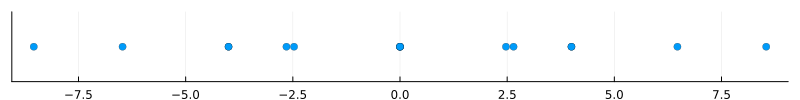

In [4]:
H = transverse_ising_hamiltonian(4, 1, 2);
s = get_spectrum(H)
println("gap: ", round(s[2]-s[1], digits =2))
println("bandwidth: ", round(s[end]-s[1],digits=3))

scatter(s, zeros(length(s)), ylim=(-1,1),yticks=false, ylabel="", label="", aspect_ratio=:auto, size=(800,100))


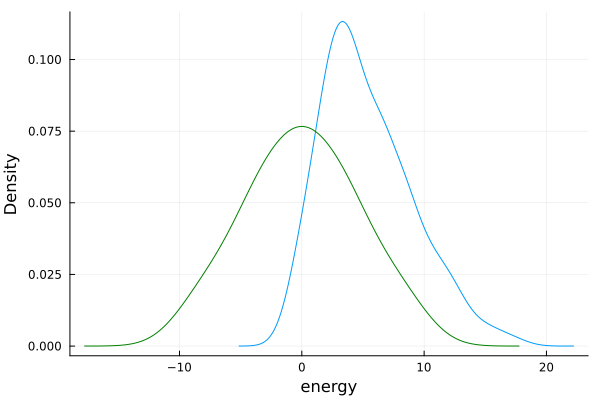

3-element Vector{Float64}:
 2.4721359549995903
 4.271558410139724
 7.999999999999998

In [6]:
bohr = Float64[]
for i in 1:(length(s)-1)
    for j in (i+1):length(s)
        push!(bohr, s[j]-s[i])
        if bohr[end] < 0
            println(i,j, bohr[end])
        end
    end
end

p = density(bohr; legend=false, xlabel="Bohr frequency", ylabel="Density")
density!(p, s; legend=false, xlabel="energy", ylabel="Density", color =:green)
display(p)

quantile(bohr, [0.25, 0.5, 0.75])  # 25%, 50% (median), and 75% quantiles

In [7]:
h = fit(Histogram, bohr, nbins=30)
peak_bin = argmax(h.weights)
h.edges[1][peak_bin]

2.0

### Superoperator construction and analysis ###